# Advanced Mean Reversion Strategy
This notebook implements the improved mean-reversion strategy on SPY with:
- ±2 Z-score threshold
- 100-day moving average trend filter
- Sharpe ratio and max drawdown calculation
  

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download SPY data
data = yf.download("SPY", start="2018-01-01", end="2023-01-01")[['Close']]
data.columns = ['price']

[*********************100%***********************]  1 of 1 completed


In [4]:
window = 20
data['rolling_mean'] = data['price'].rolling(window).mean()
data['rolling_std'] = data['price'].rolling(window).std()
data['z_score'] = (data['price'] - data['rolling_mean']) / data['rolling_std']

# Long-term trend filter (100-day moving average)
data['long_ma'] = data['price'].rolling(100).mean()

In [6]:
data['signal'] = 0

# Buy: Z-score < -2 and price above 100-day MA
data.loc[(data['z_score'] < -2) & (data['price'] > data['long_ma']), 'signal'] = 1

# Sell: Z-score > 2 and price below 100-day MA
data.loc[(data['z_score'] > 2) & (data['price'] < data['long_ma']), 'signal'] = -1

In [8]:
data['signal'] = 0

# Buy: Z-score < -2 and price above 100-day MA
data.loc[(data['z_score'] < -2) & (data['price'] > data['long_ma']), 'signal'] = 1

# Sell: Z-score > 2 and price below 100-day MA
data.loc[(data['z_score'] > 2) & (data['price'] < data['long_ma']), 'signal'] = -1

In [10]:
data['position'] = data['signal'].shift(1).fillna(0)
data['returns'] = data['price'].pct_change()
data['strategy_returns'] = data['position'] * data['returns']

In [12]:
# Cumulative returns
data['cumulative_returns'] = (1 + data['returns']).cumprod()
data['strategy_cumulative'] = (1 + data['strategy_returns']).cumprod()

# Sharpe ratio
sharpe = data['strategy_returns'].mean() / data['strategy_returns'].std() * np.sqrt(252)

# Max drawdown
cumulative_max = data['strategy_cumulative'].cummax()
drawdown = (data['strategy_cumulative'] - cumulative_max) / cumulative_max
max_drawdown = drawdown.min()

sharpe, max_drawdown

(-0.04263223442392407, -0.0543802364201181)

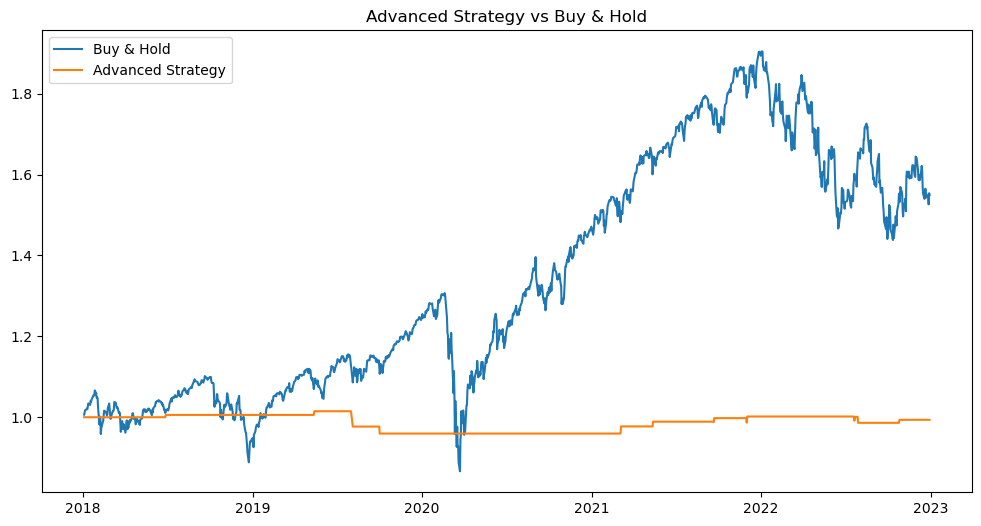

In [14]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['cumulative_returns'], label='Buy & Hold')
plt.plot(data.index, data['strategy_cumulative'], label='Advanced Strategy')
plt.legend()
plt.title('Advanced Strategy vs Buy & Hold')
plt.show()

## Observations
- Strategy uses stricter Z-score thresholds (±2) and trend filter
- Reduces overtrading compared to basic strategy
- Sharpe ratio and max drawdown give risk-adjusted performance
- This notebook highlights improvement over the basic version